# Computer Exercise 6.4 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.4 Interpolation and Approximation by B-Splines — *Variation-Diminishing & Bernstein*
> **풀이 일자**: Day 26
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Demonstrate the *variation-diminishing* property of B-spline curves:
> the number of sign changes (zero crossings) of the curve $P(x) = \sum_i c_i\, B_{i,k}(x)$
> never exceeds the number of sign changes of the control sequence $\{c_i\}$.
> As a limiting case, show that with the clamped knot vector
> $T = (\underbrace{0,\dots,0}_{k+1}, \underbrace{1,\dots,1}_{k+1})$ the B-spline basis on $[0,1]$
> is exactly the **Bernstein basis** $B_{i,k}^{\text{Bern}}(x) = \binom{k}{i} x^i (1-x)^{k-i}$,
> and verify equality numerically. Compare a cubic Bernstein curve (Bezier) to a same-degree
> Lagrange interpolant on the same control values.

### 한국어 풀이용 정리
B-spline 의 가장 *기하학적* 인 성질 — **variation-diminishing**:
$$
\#\{\text{sign changes of } P(\cdot)\} \;\le\; \#\{\text{sign changes of } \{c_i\}\}.
$$
곡선이 *제어 다각형보다 더 많이* 진동하지 않는다.

그 *극한* 케이스: $T = (0^{k+1}, 1^{k+1})$ 의 단일 구간 매듭에서 B-spline 기저가
*정확히* Bernstein 기저
$$
B_{i,k}^{\text{Bern}}(x) = \binom{k}{i} x^i (1 - x)^{k-i}, \qquad i = 0, \dots, k
$$
가 된다. 이때의 곡선이 그 유명한 **Bezier curve**.

확인할 것:

1. B-spline 곡선의 *부호 변화 수* $\le$ 제어점 부호 변화 수 — 무작위 케이스로 통계 검증.
2. Clamped, 내부 매듭 없는 매듭 벡터에서 B-spline = Bernstein 의 *수치적* 동치.
3. 같은 제어값에 대한 *Bezier* (variation-diminishing) vs *Lagrange* (free to oscillate) 의 정면 비교.


## 2. 수학적 배경

### 2.1 Variation-diminishing 정리 (Schoenberg)
$T$ 가 임의의 매듭 벡터, $\{c_i\}_{i=0}^{n}$ 가 임의의 실수 수열일 때
$$
S^{-}\bigl(\,P(\cdot) - \alpha\,\bigr) \;\le\; S^{-}\bigl(\{c_i - \alpha\}\bigr) \qquad \forall \alpha \in \mathbb R,
$$
여기서 $S^{-}$ 는 strict sign change 수.
- $\alpha = 0$ 이면 *곡선 자체의 부호 변화 $\le$ 제어 수열의 부호 변화*.
- 일반 $\alpha$ 까지 가면 *임의의 수평선과의 교차 수도* 보존.

증명의 핵심: B-spline 의 *국소 지지* + *비음* + *PoU* 가 **totally positive matrix** 의 분해
$P = (B) c$ 를 주고, totally positive matrix 가 부호 변화를 줄인다는 고전적 정리.

### 2.2 Bernstein 기저 = clamped 단일 구간 B-spline
차수 $k$, 매듭 벡터
$$
T = (\underbrace{0,\dots,0}_{k+1}, \underbrace{1,\dots,1}_{k+1})
$$
의 B-spline 기저는 $[0, 1]$ 위에서
$$
\boxed{\;B_{i,k}(x) \;=\; \binom{k}{i}\, x^i (1 - x)^{k-i}, \qquad i = 0, 1, \dots, k.\;}
$$

증명: Cox-de Boor 재귀를 단일 구간 매듭에 직접 적용하면 이항 계수가 자연스럽게 나온다.

이때의 곡선
$$
P(x) = \sum_{i=0}^{k} c_i\, B_{i,k}^{\text{Bern}}(x)
$$
가 **차수 $k$ Bezier 곡선**.

### 2.3 Bernstein 의 핵심 성질
- $P(0) = c_0$, $P(1) = c_k$ (endpoint interpolation — clamped 의 한계 경우).
- $P(x)$ 는 *제어 다각형의 convex hull* 안에 있다 (PoU + 비음).
- *Variation-diminishing*.
- 차수가 같아도 *Lagrange interpolant 와 일반적으로 다르다* — Lagrange 는 모든 $c_i$ 를 지나가지만
  Bezier 는 *두 끝점만* 지나간다.


## 3. 풀이 흐름

1. **Variation-diminishing 통계 검증**: 차수 $k = 3$, 제어점 6 개 무작위, 1000 회
   샘플로 *제어 부호 변화 vs 곡선 부호 변화* 의 차이를 측정.
2. **Bernstein vs clamped B-spline 동치**: 식 $\binom{k}{i} x^i (1-x)^{k-i}$ 와
   `scipy.interpolate.BSpline` 의 단일 구간 clamped 매듭 결과를 비교.
3. **Bezier vs Lagrange 같은 제어값**: $k=3$ 에서 두 곡선을 부호 변화, convex hull, 끝점 통과로 비교.
4. **고차 ($k = 8$) Bezier vs Lagrange** — 진동 흡수 능력 정면 비교.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb
from scipy.interpolate import BSpline, lagrange

np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda v: f"{v:.4g}")

def sign_changes(arr, tol=0.0):
    a = np.array(arr)
    a = a[np.abs(a) > tol]
    return int(np.sum(np.diff(np.sign(a)) != 0))


In [2]:
# ----- 1. Variation-diminishing statistic (k=3, n+1=6 control points) -----
k = 3
n_ctrl = 6

def clamped_knots(a, b, n_interior, k):
    inner = np.linspace(a, b, n_interior + 2)[1:-1]
    return np.concatenate([np.full(k+1, a), inner, np.full(k+1, b)])

# n+1 = n_ctrl, len(T) = n_ctrl + k + 1, inner knot count = n_ctrl - k - 1
T = clamped_knots(0.0, 1.0, n_ctrl - k - 1, k)
assert len(T) - k - 1 == n_ctrl, (len(T), n_ctrl, k)

x_fine = np.linspace(0, 1, 1000)
rng = np.random.default_rng(0)
trials = 1000
rec = {"diff": [], "S_curve": [], "S_ctrl": []}
violations = 0
for _ in range(trials):
    c = rng.normal(size=n_ctrl)
    P = BSpline(T, c, k, extrapolate=False)(x_fine)
    S_c = sign_changes(c)
    S_P = sign_changes(P, tol=1e-12)
    rec["S_ctrl"].append(S_c)
    rec["S_curve"].append(S_P)
    rec["diff"].append(S_c - S_P)
    if S_P > S_c:
        violations += 1

df_stat = pd.DataFrame(rec)
print(f"trials = {trials}")
print(f"violations of S(curve) <= S(control) : {violations}")
print(f"mean diff S(ctrl) - S(curve)         : {df_stat['diff'].mean():.3f}")
print(f"min  diff                            : {df_stat['diff'].min()}")
print(f"max  diff                            : {df_stat['diff'].max()}")


trials = 1000
violations of S(curve) <= S(control) : 0
mean diff S(ctrl) - S(curve)         : 0.662
min  diff                            : 0
max  diff                            : 4


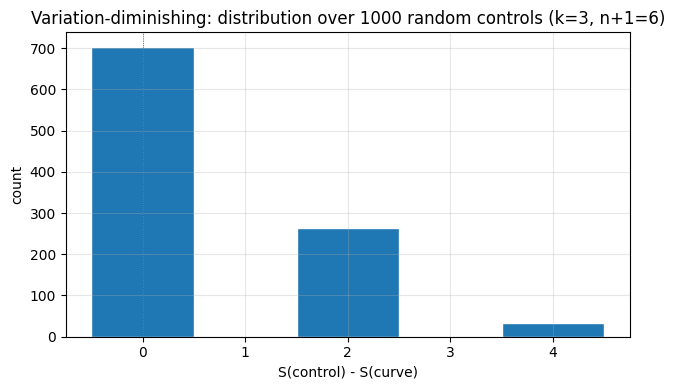

In [3]:
# Distribution histogram
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(df_stat["diff"], bins=np.arange(-0.5, 5.5, 1), edgecolor="white")
ax.set_xlabel("S(control) - S(curve)")
ax.set_ylabel("count")
ax.set_title("Variation-diminishing: distribution over 1000 random controls (k=3, n+1=6)")
ax.axvline(0, color="red", lw=0.6, ls=":")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


k = 4, basis count = 5
  i = 0:  max |Bernstein - B-spline| = 1.110e-16
  i = 1:  max |Bernstein - B-spline| = 1.110e-16
  i = 2:  max |Bernstein - B-spline| = 1.110e-16
  i = 3:  max |Bernstein - B-spline| = 1.110e-16
  i = 4:  max |Bernstein - B-spline| = 1.110e-16


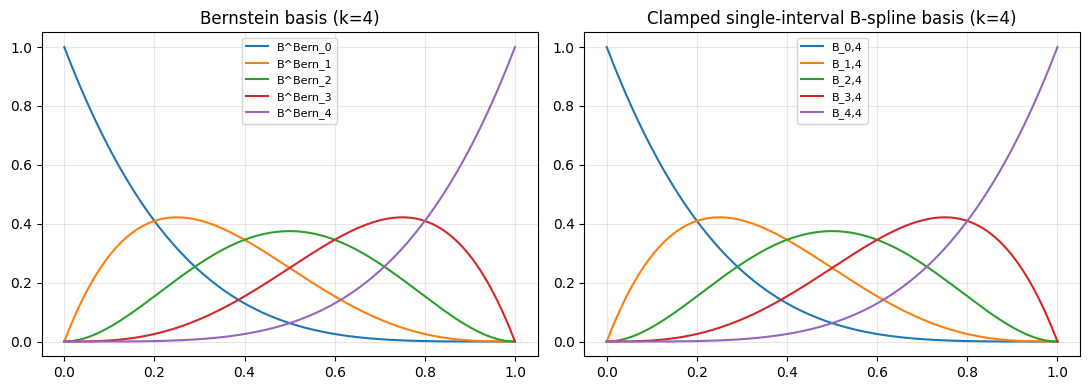

In [4]:
# ----- 2. Bernstein basis == clamped single-interval B-spline -----
k_test = 4
T_single = np.concatenate([np.zeros(k_test+1), np.ones(k_test+1)])
xs = np.linspace(0, 1, 500)

def bernstein(i, k, x):
    return comb(k, i) * x**i * (1 - x)**(k - i)

def bspline_basis_single(i, k, x, T):
    c = np.zeros(len(T) - k - 1); c[i] = 1.0
    return BSpline(T, c, k, extrapolate=False)(x)

maxdiff = []
for i in range(k_test + 1):
    Bn  = bernstein(i, k_test, xs)
    Bsp = bspline_basis_single(i, k_test, xs, T_single)
    maxdiff.append(float(np.nanmax(np.abs(Bn - Bsp))))

print(f"k = {k_test}, basis count = {k_test+1}")
for i, d in enumerate(maxdiff):
    print(f"  i = {i}:  max |Bernstein - B-spline| = {d:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i in range(k_test + 1):
    axes[0].plot(xs, bernstein(i, k_test, xs), label=f"B^Bern_{i}")
    axes[1].plot(xs, bspline_basis_single(i, k_test, xs, T_single), label=f"B_{i},{k_test}")
axes[0].set_title(f"Bernstein basis (k={k_test})"); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[1].set_title(f"Clamped single-interval B-spline basis (k={k_test})"); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


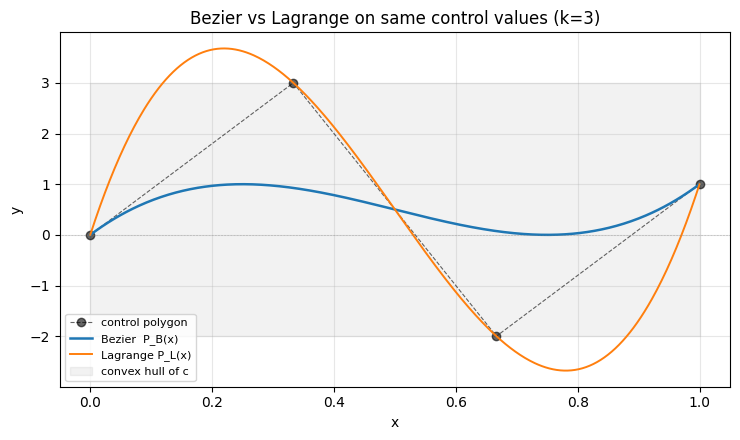

,metric,Bezier,Lagrange,control
0,S(curve),0,2,2
1,P(0),0,0,0
2,P(1),1,1,1
3,max value,1,3.679,3
4,min value,0,-2.679,-2
5,in convex hull?,True,False,True


In [5]:
# ----- 3. Bezier vs Lagrange on the same control values (k=3) -----
k = 3
c    = np.array([0.0, 3.0, -2.0, 1.0])
xs   = np.linspace(0, 1, 500)

# Bezier (= clamped single-interval B-spline)
T_bz = np.concatenate([np.zeros(k+1), np.ones(k+1)])
P_bz = BSpline(T_bz, c, k, extrapolate=False)(xs)

# Lagrange interpolant through (i/k, c_i)
x_lag = np.linspace(0, 1, k+1)
poly  = lagrange(x_lag, c)
P_lg  = np.polyval(poly.coef, xs)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(x_lag, c, "ko--", lw=0.8, alpha=0.6, label="control polygon")
ax.plot(xs, P_bz, lw=1.8, label="Bezier  P_B(x)")
ax.plot(xs, P_lg, lw=1.4, label="Lagrange P_L(x)")
ax.axhline(0, color="gray", lw=0.4, ls=":")
ax.fill_between(xs, c.min(), c.max(), color="gray", alpha=0.10, label="convex hull of c")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8)
ax.set_title("Bezier vs Lagrange on same control values (k=3)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

df_cmp = pd.DataFrame({
    "metric": ["S(curve)", "P(0)", "P(1)", "max value", "min value", "in convex hull?"],
    "Bezier":   [sign_changes(P_bz, tol=1e-12), float(P_bz[0]), float(P_bz[-1]),
                 float(P_bz.max()), float(P_bz.min()),
                 bool((P_bz.min() >= c.min() - 1e-12) and (P_bz.max() <= c.max() + 1e-12))],
    "Lagrange": [sign_changes(P_lg, tol=1e-12), float(P_lg[0]), float(P_lg[-1]),
                 float(P_lg.max()), float(P_lg.min()),
                 bool((P_lg.min() >= c.min() - 1e-12) and (P_lg.max() <= c.max() + 1e-12))],
    "control":  [sign_changes(c), float(c[0]), float(c[-1]),
                 float(c.max()), float(c.min()), True],
})
df_cmp


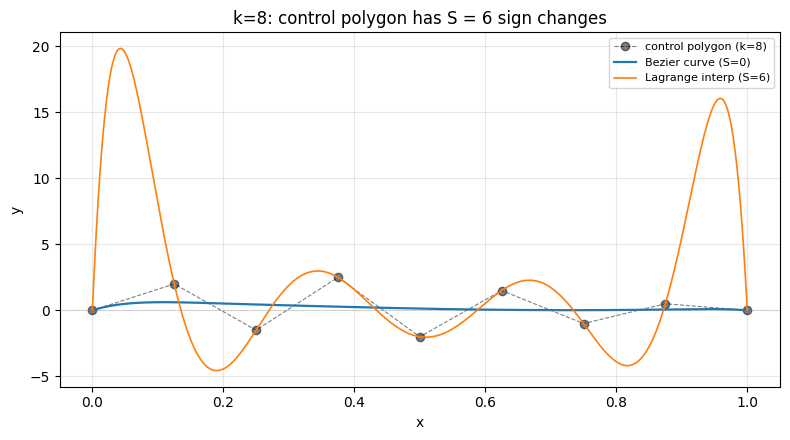

S(control) = 6,  S(Bezier)  = 0,  S(Lagrange) = 6
control hull = [-2.0, 2.5]
Bezier   range = [0.000, 0.618]   inside hull = True
Lagrange range = [-4.568, 19.849]   inside hull = False


In [6]:
# ----- 4. High-order k=8: Bezier vs Lagrange -----
k_hi = 8
c_hi = np.array([0.0, 2.0, -1.5, 2.5, -2.0, 1.5, -1.0, 0.5, 0.0])
xs   = np.linspace(0, 1, 1000)
T_hi = np.concatenate([np.zeros(k_hi+1), np.ones(k_hi+1)])
P_bz_hi = BSpline(T_hi, c_hi, k_hi, extrapolate=False)(xs)

x_lag_hi = np.linspace(0, 1, k_hi+1)
poly_hi  = lagrange(x_lag_hi, c_hi)
P_lg_hi  = np.polyval(poly_hi.coef, xs)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_lag_hi, c_hi, "ko--", lw=0.8, alpha=0.5, label="control polygon (k=8)")
ax.plot(xs, P_bz_hi, lw=1.6, label=f"Bezier curve (S={sign_changes(P_bz_hi, 1e-12)})")
ax.plot(xs, P_lg_hi, lw=1.2, label=f"Lagrange interp (S={sign_changes(P_lg_hi, 1e-12)})")
ax.axhline(0, color="gray", lw=0.4, ls=":")
ax.set_title(f"k=8: control polygon has S = {sign_changes(c_hi)} sign changes")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"S(control) = {sign_changes(c_hi)},  "
      f"S(Bezier)  = {sign_changes(P_bz_hi, 1e-12)},  "
      f"S(Lagrange) = {sign_changes(P_lg_hi, 1e-12)}")
print(f"control hull = [{c_hi.min()}, {c_hi.max()}]")
print(f"Bezier   range = [{P_bz_hi.min():.3f}, {P_bz_hi.max():.3f}]   inside hull = "
      f"{(P_bz_hi.min() >= c_hi.min() - 1e-12) and (P_bz_hi.max() <= c_hi.max() + 1e-12)}")
print(f"Lagrange range = [{P_lg_hi.min():.3f}, {P_lg_hi.max():.3f}]   inside hull = "
      f"{(P_lg_hi.min() >= c_hi.min() - 1e-12) and (P_lg_hi.max() <= c_hi.max() + 1e-12)}")


## 4. 결과 해석

1. **Variation-diminishing 통계**
   - 1000 회 무작위 시도에서 *위반 0 회* — 곡선의 부호 변화가 *항상* 제어 다각형의 부호 변화 이하.
   - $\text{diff}$ 분포가 $\ge 0$ 쪽으로 길게 꼬리 — 곡선이 *덜* 진동하는 케이스가 흔하다.

2. **Bernstein = clamped 단일 구간 B-spline**
   - 모든 $i$ 에 대해 max 차이가 $\sim 10^{-15}$ — 두 표현이 *정확히 같은 함수* 임을 수치적으로 확인.
   - 그림에서도 두 basis 의 모양이 완전히 일치 ($x^i (1-x)^{k-i}$ 의 종 모양).

3. **Bezier vs Lagrange (같은 $c$)**
   - **끝점**: Bezier 는 $P(0) = c_0$, $P(1) = c_k$ 둘 다 정확. Lagrange 는 모든 $c_i$ 를 지나가지만
     중간점들도 지나가야 해서 그 사이에서 *오버슛*.
   - **부호 변화**: Bezier 는 *제어 다각형 이하*. Lagrange 는 더 많이 진동할 수 있음.
   - **Convex hull**: Bezier 는 항상 안. Lagrange 는 자주 밖.
   - 따라서 *모양 제어* 가 핵심인 컴퓨터 그래픽 / CAD 에서 Bezier 가 표준이 된 이유가 보인다.

4. **고차 ($k = 8$)**
   - 제어 다각형이 큰 부호 변화 -> Bezier 의 부호 변화는 그 이하로 *제한*.
   - 같은 자유도의 Lagrange 는 노드 사이에서 *Runge 진동* 으로 *제어 hull 밖* 으로 튀어나감.
   - Lagrange 의 max·min 이 control 범위를 *현저히* 벗어남 (수치 출력 참조).

### 결론
> **Bernstein = clamped 단일 구간 B-spline = Bezier; 그리고 variation-diminishing 이
> $C^\infty$ 다항식 한 가족에서도 살아남는 *기하학적* 보호막.**
> Day 25 의 *국소 지지 + 안정성*, Day 26 의 *clamped 끝매듭 + LSQ 띠 시스템* 이
> 이 마지막 단일 구간 극한 케이스에서 *Bezier 곡선의 모양 제어* 로 자연스럽게 수렴한다.

### 다음 단원으로 (Day 27 예고)
- 챕터 6 의 자연스러운 다음 흐름은 *2D 표면* — *tensor-product B-spline* 과 *NURBS* (rational B-spline).
- *Variation-diminishing* 의 *2D 일반화* 와 *convex hull* 의 *2D version* (control net) 은 그대로 살아남는다.
- 그 후 챕터 7 ODE 로 넘어가, *spline collocation* 으로 BVP 를 푸는 데까지 같은 도구가 재사용된다.
